In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, regularizers, optimizers, losses, Model
from xgboost import XGBClassifier
import gc


era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -0.5, 0.5, float('inf')]
labels = ['Severely Dry', 'Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2]
df['category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)
df["target_next_month"] = df["category"].shift(-14)
df['tp_14d_sum'] = df['tp'].rolling(window=14, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()
df = df.dropna()

features_to_drop = ['z_score', 'target_next_month', 'time', 'mean'] 

top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_14d_sum', 'category']

CNN

In [ ]:
def build_regularized_cnn(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        
        # First Convolutional Block
        # kernel_size=5 means the filter looks at 5 days at a time
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', 
                      kernel_regularizer=regularizers.l2(0.01),
                      padding='same'),
        layers.BatchNormalization(),
        # MaxPooling reduces the sequence length, keeping only the strongest signals
        layers.MaxPooling1D(pool_size=2), 
        layers.Dropout(0.3),
        
        # Second Convolutional Block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                      kernel_regularizer=regularizers.l2(0.01),
                      padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.4),
        
        # Global Pooling (Crucial for Time Series CNNs)
        # Instead of 'Flatten', which causes massive overfitting, this averages the feature maps across the remaining time steps.
        layers.GlobalAveragePooling1D(),
        
        # Final Classification Head
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss=losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

def train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    """Trains the CNN and handles one-hot label weight mapping."""
    print(f"\n--- CNN Training: Lead Time {lead_time} ---")
    
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_regularized_cnn(input_shape)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        class_weight=class_weights_dict, 
        callbacks=callbacks,
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, f1, model

Transformer

In [ ]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    """Helper function to create a single Transformer block."""
    # Attention and Normalization
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

def build_transformer_model(input_shape):
    """Assembles the Transformer architecture."""
    inputs = layers.Input(shape=input_shape)

    # Transformer Block
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)

    # Global Average Pooling (Reduces sequence to a vector)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)

    # Output Layer
    outputs = layers.Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam', 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

def train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    """Trains the Transformer for a specific lead time and returns accuracy."""
    print(f"\n--- Starting Transformer Training: Lead Time {lead_time} ---")
    
    # Build model based on input data shape
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_transformer_model(input_shape)

    # Define Early Stopping
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True
    )

    # Train
    model.fit(
        X_train, y_train, 
        epochs=100, 
        batch_size=64, 
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        class_weight=class_weights_dict,
        verbose=0 # Set to 1 to track the progress of every epoch
    )

    # Evaluate
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Lead Time {lead_time} Results -> Accuracy: {acc:.4f}, F1: {f1:.4f}")
    
    return acc, f1, model

XGboost

In [ ]:
def train_evaluate_xgboost(X_train, y_train, X_test, y_test, sample_weights, lead_time):
    """Trains XGBoost and handles 3D-to-2D flattening and label conversion."""
    print(f"\n--- XGBoost Training: Lead Time {lead_time} ---")

    # Define Model (using your specific parameters)
    model = XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1.0,
        objective='multi:softmax',
        num_class=len(np.unique(y_train)), # Dynamically set classes
        random_state=42
    )

    # Train
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # Evaluate
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    # print(f"XGBoost: Lead Time {lead_time} - Acc: {acc:.4f}, F1 (Macro): {f1:.4f}")
    
    return acc, f1

def train_evaluate_xgboost(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    """Trains XGBoost using sample_weight array created from class_weight dict."""
    print(f"\n--- XGBoost Training: Lead Time {lead_time} ---")

    # Convert class_weights dictionary to a sample_weight array
    # This creates an array where each entry corresponds to the weight of that specific row
    sample_weights = np.array([class_weights_dict[t] for t in y_train])

    model = XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.3,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1.0,
        objective='multi:softmax',
        num_class=3,
        random_state=42
    )

    # Use the newly created sample_weights array here
    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return acc, f1, model

Data preparation function

In [ ]:
def prepare_data_for_lead_time(df, lead_time, seq_length=14):
    """
    Dynamically shifts the target variable to the requested lead time
    and prepares the 3D sequences for the LSTM.
    Also returns persistence-baseline labels.
    """
    cols_to_drop = ['target_next_month', 'time']
    features_df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    features_df = features_df[top_features]

    y_raw = df['category'].values
    X_raw = features_df.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    X_seq, y_seq, y_persist = [], [], []

    for i in range(len(X_scaled) - seq_length - lead_time + 1):
        X_seq.append(X_scaled[i:i + seq_length])

        target_idx = i + seq_length + lead_time - 1
        y_seq.append(y_raw[target_idx])

        # Persistence baseline: predict the last observed class in the input window
        y_persist.append(y_raw[i + seq_length - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq).astype(int)
    y_persist = np.array(y_persist).astype(int)

    y_encoded = to_categorical(y_seq, num_classes=3)

    split_idx = int(len(X_seq) * 0.8)

    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

    y_persist_train = y_persist[:split_idx]
    y_persist_test = y_persist[split_idx:]
    y_true_test = y_seq[split_idx:]

    y_train_flat = np.argmax(y_train, axis=1)
    weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_flat),
        y=y_train_flat
    )
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    return X_train, X_test, y_train, y_test, class_weights_dict, y_persist_test, y_true_test


def plot_learning_curves(history, lead_time):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{lead_time}-Day Lead Time: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{lead_time}-Day Lead Time: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def train_evaluate_lstm(X_train, X_test, y_train, y_test, weights_dict, lead_time):
    model = Sequential()

    model.add(
        LSTM(
            units=16,
            input_shape=(X_train.shape[1], X_train.shape[2]),
            kernel_regularizer=regularizers.l2(0.01),
            recurrent_regularizer=regularizers.l2(0.01),
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )

    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    print(f"\nTraining model for {lead_time}-Day lead time...")

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        class_weight=weights_dict,
        verbose=0
    )

    # plot_learning_curves(history, lead_time)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Done! {lead_time}-Day Validation Accuracy: {accuracy:.4f}")

    return accuracy, accuracy, model

In [ ]:
def plot_hero_predictability(results_df):
    plt.figure(figsize=(15, 10))

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['LSTM Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='LSTM Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Persistence Baseline (%)'],
        marker='s',
        linewidth=2.5,
        label='Persistence Baseline'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['CNN Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='CNN Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Transformer Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='Transformer Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['XGBoost Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='XGBoost Performance'
    )

    plt.axhline(
        y=33.3,
        linestyle='--',
        linewidth=2,
        label='Random Chance (33.3%)'
    )

    plt.title('Predictability Cliff: Hydrological Memory Fades with Lead Time')
    plt.xlabel('Lead Time (Days)')
    plt.ylabel('Accuracy (%)')
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

lead_times_to_test = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 14] 
results_list = []

print("Starting Lead-Time Analysis...")

for lt in lead_times_to_test:
    X_train, X_test, y_train, y_test, class_weights, y_persist_test, y_true_test = prepare_data_for_lead_time(
        df, lead_time=lt)
    
    # LSTM
    val_acc_lstm = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)

    # Persistence
    persistence_acc = np.mean(y_persist_test == y_true_test)

    # CNN
    val_acc_cnn, val_f1_cnn = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)

    # transformer
    val_acc_transformer, val_f1_transformer = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)
    
    # XGboost
    # "Squash" X into 2D for XGBoost
    # This turns (Samples, 14, 11) into (Samples, 314)
    X_train_xgb = X_train.reshape(X_train.shape[0], -1)
    X_test_xgb = X_test.reshape(X_test.shape[0], -1)

    # Convert y back to Integers for XGBoost
    # Turns [[1,0,0], [0,1,0]] into [0, 1]
    y_train_xgb = np.argmax(y_train, axis=1)
    y_test_xgb = np.argmax(y_test, axis=1)

    val_acc_xgboost, val_f1_xgboost = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

    results_list.append({
        'Lead Time (Days)': lt,
        'LSTM Accuracy (%)': round(val_acc_lstm * 100, 2),
        'CNN Accuracy (%)': round(val_acc_cnn * 100, 2),
        'Transformer Accuracy (%)': round(val_acc_transformer * 100, 2),
        'XGBoost Accuracy (%)': round(val_acc_xgboost * 100, 2),
        'Persistence Baseline (%)': round(persistence_acc * 100, 2)
    })

    # CRITICAL: CLEAR MEMORY
    # Wipe the TensorFlow/Keras models from RAM/GPU
    tf.keras.backend.clear_session()
    
    # Delete the large data arrays to free up space
    del X_train, X_test, X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb, y_train, y_test
    
    # Force Python to clean up
    gc.collect()


results_df = pd.DataFrame(results_list)

print("\n" + "=" * 50)
print(" LEAD-TIME PREDICTABILITY ANALYSIS ")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

# Final hero plot
plot_hero_predictability(results_df)

#### XAI comparison models plot


--- XGBoost Training: Lead Time 1 ---

--- Starting Transformer Training: Lead Time 1 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Lead Time 1 Results -> Accuracy: 0.7701, F1: 0.7670

--- CNN Training: Lead Time 1 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training model for 1-Day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done! 1-Day Validation Accuracy: 0.8520


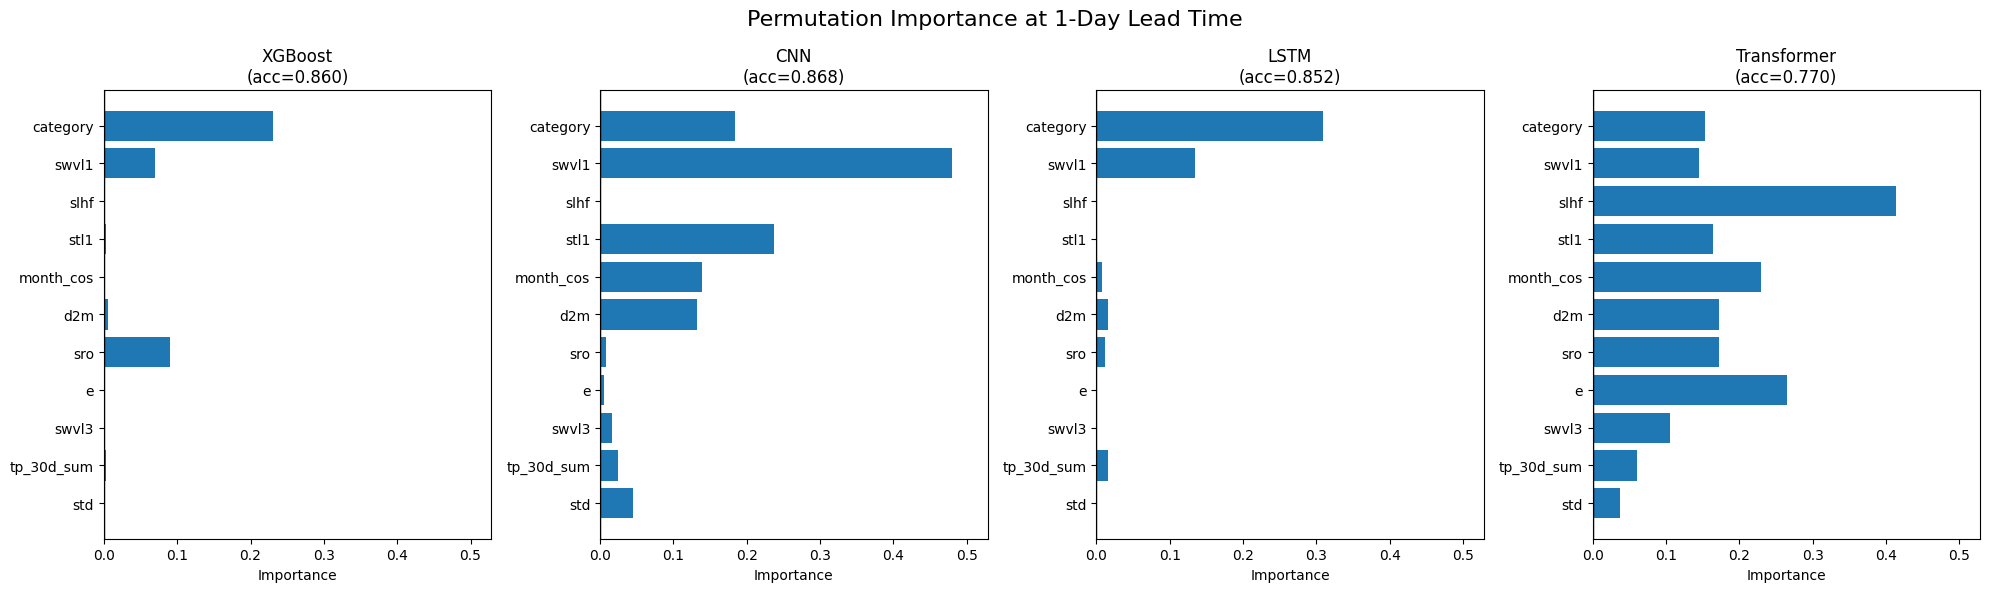

In [ ]:
def permutation_importance_general(model, X_test, y_test, feature_names, model_type="deep"):
    """
    Permutation importance for:
      - model_type="deep": LSTM / CNN / Transformer expecting 3D input (samples, timesteps, features)
      - model_type="xgb": XGBoost expecting 2D input, but we permute on the original 3D tensor
                         and flatten only for prediction
    Returns a DataFrame sorted from least to most important.
    """
    # Convert y_test to class indices if one-hot
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # Helper for prediction
    def predict_classes(X):
        if model_type == "xgb":
            X_in = X.reshape(X.shape[0], -1)  # flatten to 2D for XGBoost
            y_prob = model.predict_proba(X_in)
            return np.argmax(y_prob, axis=1)
        else:
            y_prob = model.predict(X, verbose=0)
            return np.argmax(y_prob, axis=1)

    # Baseline accuracy
    y_pred_base = predict_classes(X_test)
    baseline_acc = accuracy_score(y_true, y_pred_base)

    importances = []

    for i, feature in enumerate(feature_names):
        X_perm = X_test.copy()

        # Permute one feature across all samples and timesteps
        feat_block = X_perm[:, :, i].copy()
        flat_vals = feat_block.flatten()
        np.random.shuffle(flat_vals)
        X_perm[:, :, i] = flat_vals.reshape(feat_block.shape)

        y_pred_perm = predict_classes(X_perm)
        perm_acc = accuracy_score(y_true, y_pred_perm)

        importance = baseline_acc - perm_acc
        importances.append(importance)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=True)

    return importance_df, baseline_acc


def plot_four_model_importance(models, X_test, y_test, feature_names, lead_time):
    """
    models = dict with keys:
      'XGBoost', 'CNN', 'LSTM', 'Transformer'
    and values = trained model objects.
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharex=True)

    model_order = ["XGBoost", "CNN", "LSTM", "Transformer"]
    model_types = {
        "XGBoost": "xgb",
        "CNN": "deep",
        "LSTM": "deep",
        "Transformer": "deep"
    }

    importance_results = {}

    # Compute importance for all models
    for model_name in model_order:
        model = models[model_name]
        importance_df, baseline_acc = permutation_importance_general(
            model=model,
            X_test=X_test,
            y_test=y_test,
            feature_names=feature_names,
            model_type=model_types[model_name]
        )
        importance_results[model_name] = (importance_df, baseline_acc)

    # Compute average importance across models (for ordering)
    all_importances_df = pd.concat([
        df.set_index("Feature")["Importance"]
        for df, _ in importance_results.values()
    ], axis=1)

    avg_importance = all_importances_df.mean(axis=1).sort_values()

    common_order = avg_importance.index

    # Global x-axis scaling
    global_max = max(
        df["Importance"].max() for df, _ in importance_results.values()
    )

    # Plot
    for ax, model_name in zip(axes, model_order):
        importance_df, baseline_acc = importance_results[model_name]

        importance_df = importance_df.set_index("Feature").loc[common_order].reset_index()

        ax.barh(importance_df["Feature"], importance_df["Importance"])
        ax.set_title(f"{model_name}\n(acc={baseline_acc:.3f})")
        ax.set_xlim(0, global_max * 1.1)
        ax.axvline(0, color='black', linewidth=1)

        ax.set_xlabel("Importance")
        ax.set_ylabel("")

    fig.suptitle(f"Permutation Importance at {lead_time}-Day Lead Time", fontsize=16)
    plt.tight_layout()
    plt.show()


lt = 1
X_train, X_test, y_train, y_test, class_weights, y_persist_test, y_true_test = prepare_data_for_lead_time(df, lead_time=lt)

# XGboost
# "Squash" X into 2D for XGBoost
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# Convert y back to Integers for XGBoost
# Turns [[1,0,0], [0,1,0]] into [0, 1]
y_train_xgb = np.argmax(y_train, axis=1)
y_test_xgb = np.argmax(y_test, axis=1)

val_acc_xgboost, val_f1_xgboost, xgb_model_1 = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

# transformer
val_acc_transformer, val_f1_transformer, transformer_model_1 = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)

# CNN
val_acc_cnn, val_f1_cnn, cnn_model_1 = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)
    
# LSTM
acc_1, probs_1, lstm_model_1 = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)

final_features_1day = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']

models_1day = {
    "XGBoost": xgb_model_1,         # replace with your actual variable name
    "CNN": cnn_model_1,             # replace with your actual variable name
    "LSTM": lstm_model_1,           # replace with your actual variable name
    "Transformer": transformer_model_1  # replace with your actual variable name
}

plot_four_model_importance(
    models=models_1day,
    X_test=X_test,
    y_test=y_test,
    feature_names=final_features_1day,
    lead_time=lt
)


--- XGBoost Training: Lead Time 14 ---

--- Starting Transformer Training: Lead Time 14 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Lead Time 14 Results -> Accuracy: 0.4253, F1: 0.4050

--- CNN Training: Lead Time 14 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Training model for 14-Day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done! 14-Day Validation Accuracy: 0.4519


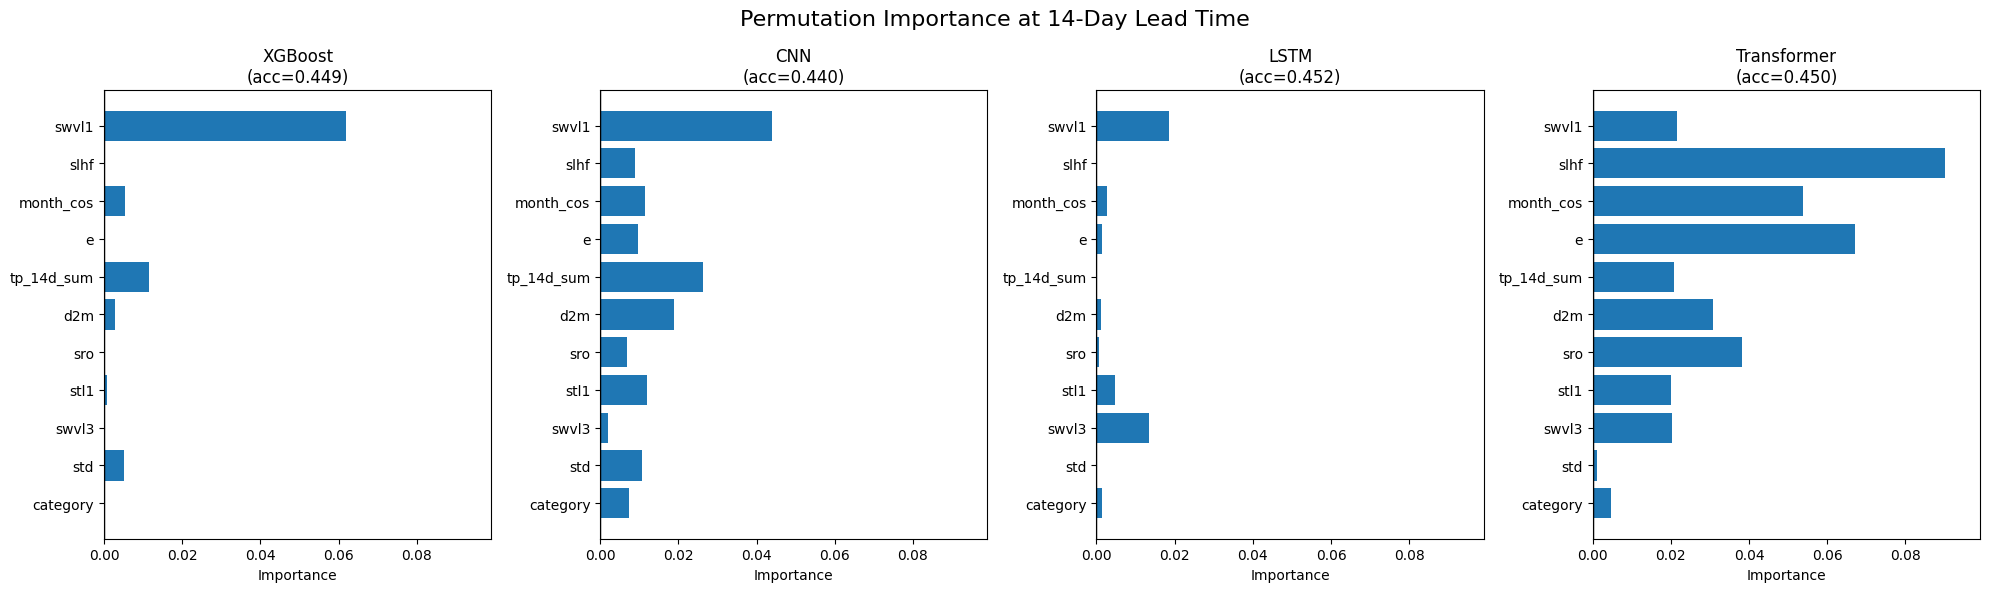

In [ ]:
lt = 14
X_train, X_test, y_train, y_test, class_weights, y_persist_test, y_true_test = prepare_data_for_lead_time(df, lead_time=lt)

# XGboost
# "Squash" X into 2D for XGBoost
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# Convert y back to Integers for XGBoost
# Turns [[1,0,0], [0,1,0]] into [0, 1]
y_train_xgb = np.argmax(y_train, axis=1)
y_test_xgb = np.argmax(y_test, axis=1)

val_acc_xgboost, val_f1_xgboost, xgb_model_14 = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

# transformer
val_acc_transformer, val_f1_transformer, transformer_model_14 = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)

# CNN
val_acc_cnn, val_f1_cnn, cnn_model_14 = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)
    
# LSTM
acc_1, probs_1, lstm_model_14 = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)

# Use the exact features the 14-day models were trained on
final_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_14d_sum', 'category']

models_14day = {
    "XGBoost": xgb_model_14,         # replace with your actual variable name
    "CNN": cnn_model_14,             # replace with your actual variable name
    "LSTM": lstm_model_14,           # replace with your actual variable name
    "Transformer": transformer_model_1  # replace with your actual variable name
}

plot_four_model_importance(
    models=models_14day,
    X_test=X_test,
    y_test=y_test,
    feature_names=final_features,
    lead_time=lt
)


--- XGBoost Training: Lead Time 14 ---

--- Starting Transformer Training: Lead Time 14 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Lead Time 14 Results -> Accuracy: 0.4365, F1: 0.4214

--- CNN Training: Lead Time 14 ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Training model for 14-Day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done! 14-Day Validation Accuracy: 0.4696


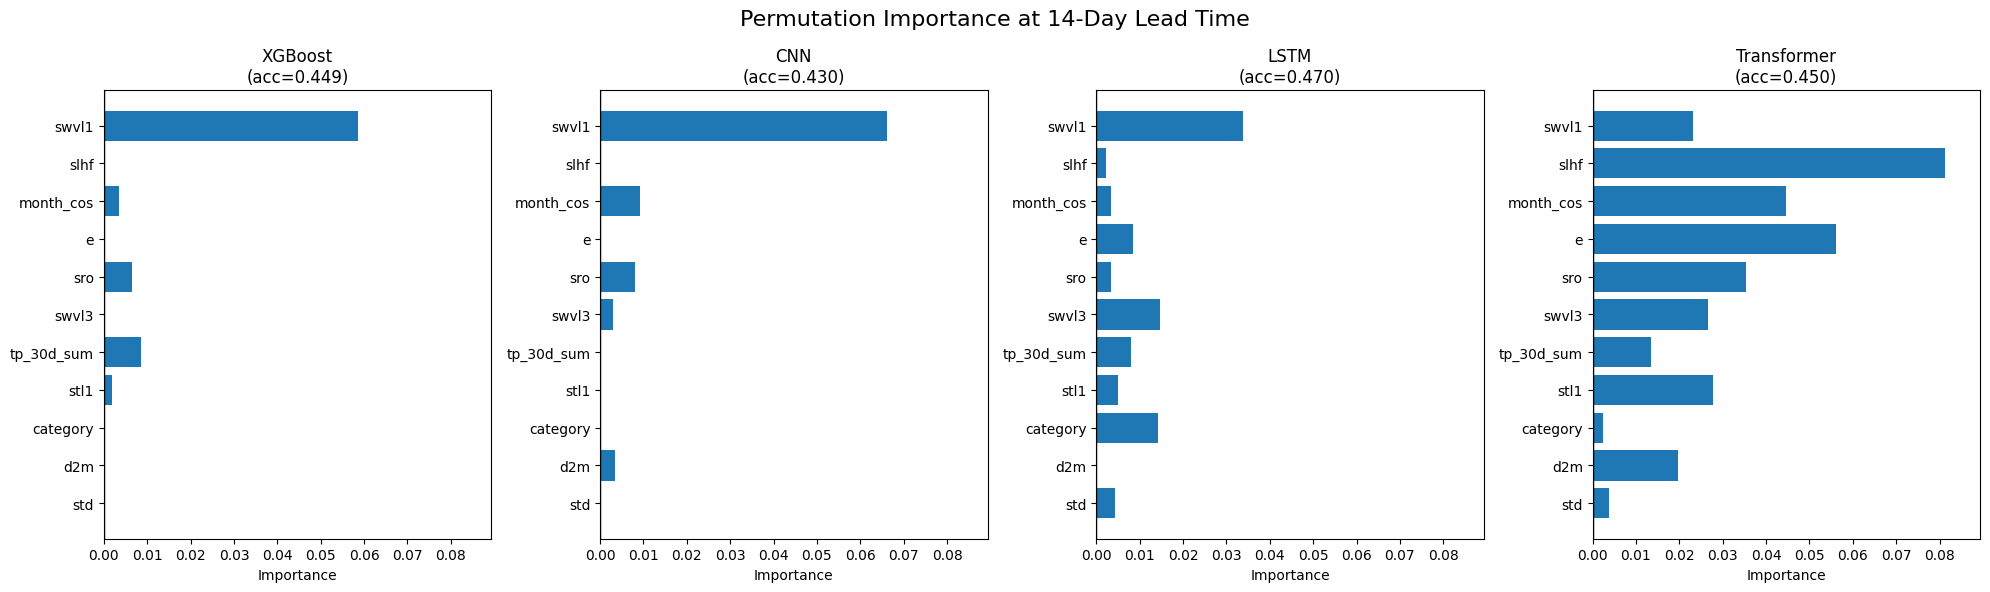

In [11]:
lt = 14
X_train, X_test, y_train, y_test, class_weights, y_persist_test, y_true_test = prepare_data_for_lead_time(df, lead_time=lt)

# XGboost
# "Squash" X into 2D for XGBoost
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# Convert y back to Integers for XGBoost
# Turns [[1,0,0], [0,1,0]] into [0, 1]
y_train_xgb = np.argmax(y_train, axis=1)
y_test_xgb = np.argmax(y_test, axis=1)

val_acc_xgboost, val_f1_xgboost, xgb_model_30 = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

# transformer
val_acc_transformer, val_f1_transformer, transformer_model_30 = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)

# CNN
val_acc_cnn, val_f1_cnn, cnn_model_30 = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)
    
# LSTM
acc_1, probs_1, lstm_model_30 = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)


# Use the exact features the 30-day models were trained on
final_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']

models_30day = {
    "XGBoost": xgb_model_30,         # replace with your actual variable name
    "CNN": cnn_model_30,             # replace with your actual variable name
    "LSTM": lstm_model_30,           # replace with your actual variable name
    "Transformer": transformer_model_1  # replace with your actual variable name
}

plot_four_model_importance(
    models=models_30day,
    X_test=X_test,
    y_test=y_test,
    feature_names=final_features,
    lead_time=lt
)